In [2]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

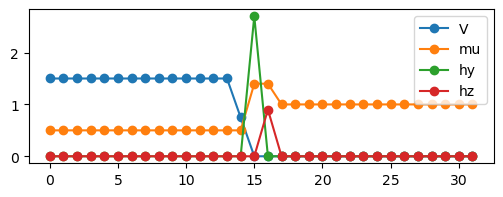

In [3]:
widthS = 15
widthF1 = 1
widthF2 = 1
widthN = 15
X, Y = widthS+widthF1+widthF2+widthN, 100
lattice = Lattice(X, Y)

t = 1
T = 0.1

muS = 0.5 * t
muF = 1.4 * t
muN = 1.0 * t
mu = np.zeros(lattice.X)
mu[:widthS] = muS
mu[widthS:widthS+widthF1+widthF2] = muF
mu[widthS+widthF1+widthF2:] = muN

h0 = 0.9 * t
hy = np.zeros_like(mu)
hz = np.zeros_like(mu)

hy[widthS:widthS+widthF1] = 3*h0
hz[widthS+widthF1:widthS+widthF1+widthF2] = h0

U=None
V_prime = None

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)
V[widthS:] = 0
V[widthS-1] = V0/2

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(hy, '-o', label='hy')
plt.plot(hz, '-o', label='hz')


plt.legend()

In [4]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.1, 0.1, -0.1, -0.1], hz=hy, hy=hz)

In [5]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, atol=1e-4, rtol=1e-3, maxiter=500, verbose=True, temperature=T)

F0:
Absolute error: 0.057015730603104525
Relative error: 57015730603.104515
Average old: 0j
Average: (0.0030113246166542417-1.679665012707569e-18j)
F_xplus:
Absolute error: 0.32431563037871736
Relative error: 14973080633.609348
Average old: (0.04516129032258065+0j)
Average: (0.08321764459084277+2.0820868685584314e-18j)
F_xmin:
Absolute error: 0.33842454163931435
Relative error: 1958642473.7829056
Average old: (0.04838709677419355+0j)
Average: (0.08576023328496833+1.8974565979261007e-18j)
F_yplus:
Absolute error: 0.3165910340635407
Relative error: 6528694082.48007
Average old: (-0.046875+0j)
Average: (-0.08361204793616972-8.139746545678606e-17j)
F_ymin:
Absolute error: 0.3165910340635408
Relative error: 6528694082.480068
Average old: (-0.046875+0j)
Average: (-0.08361204793616972+7.720619258433244e-17j)
Fuu_xplus:
Absolute error: 0.005727792827968814
Relative error: 5727792827.968814
Average old: 0j
Average: (-9.912412924459769e-19+0.0005337237903749014j)
Fuu_xmin:
Absolute error: 0.0057

In [6]:
F, Fuu, Fdd = H.get_correlations()

T/t=0.1, hy/t=0.9


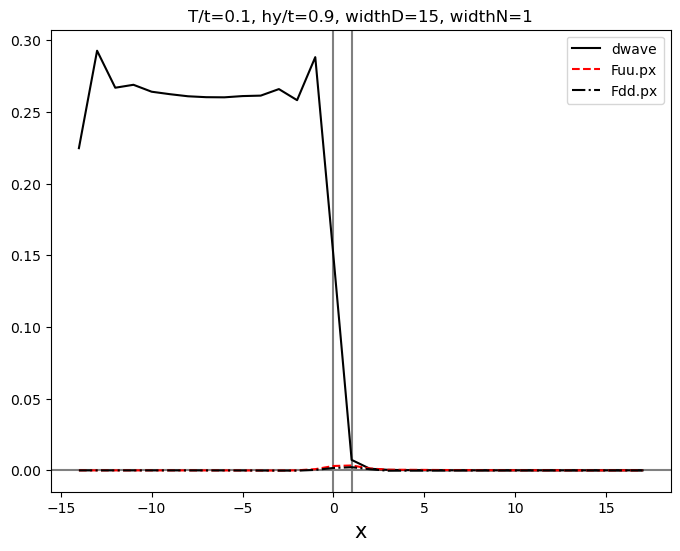

In [7]:
x = np.arange(-widthS, widthF1+widthF2+widthN) + 1

fig, axs = plt.subplots(1, 1, figsize=(8, 6))

print(f"T/t={T}, hy/t={h0}")

axs.axhline(0, color='gray')
axs.axvline(0, color='gray')
axs.axvline(widthF1, color='gray')

axs.plot(x, np.abs(F.dwave), label=r"dwave", color='black')
# axs.plot(x, np.abs(F.px), label=r"px", color='red')
axs.plot(x, np.imag(Fuu.px), "--", label=r"Fuu.px", color='red')
axs.plot(x, np.imag(Fdd.px), "-.", label=r"Fdd.px", color='black')

axs.set_xlabel("x", fontsize=15)

# axs.set_ylim(None, 0.10)
# axs.set_xlim(-5, 10)
# axs.set_xticks([-5, 0, 5, 10])
axs.set_title(f"T/t={T}, hy/t={h0}, widthD={widthS}, widthN={widthF2}", )
plt.legend()
plt.show()

T/t=0.1, hy/t=0.9


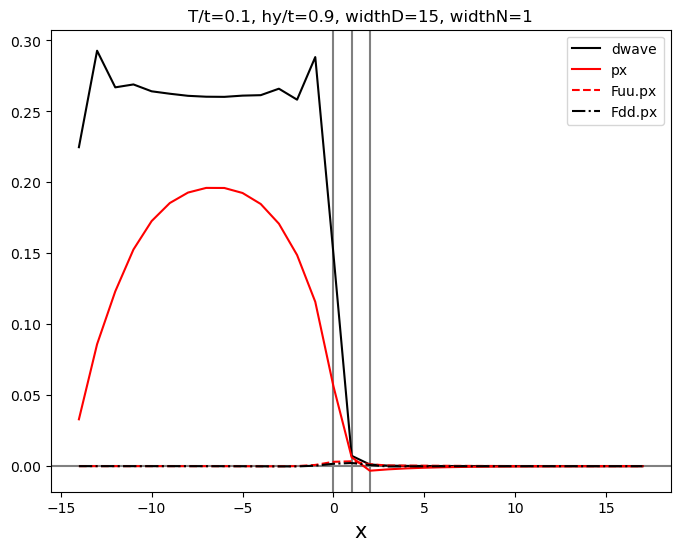

In [8]:
x = np.arange(-widthS, widthF1+widthF2+widthN) + 1

fig, axs = plt.subplots(1, 1, figsize=(8, 6))

print(f"T/t={T}, hy/t={h0}")

axs.axhline(0, color='gray')
axs.axvline(0, color='gray')
axs.axvline(widthF1, color='gray')
axs.axvline(widthF1+widthF2, color='gray')

axs.plot(x, np.abs(F.dwave), label=r"dwave", color='black')
axs.plot(x, np.real(F.px), label=r"px", color='red')
axs.plot(x, np.imag(Fuu.px), "--", label=r"Fuu.px", color='red')
axs.plot(x, np.imag(Fdd.px), "-.", label=r"Fdd.px", color='black')

axs.set_xlabel("x", fontsize=15)

# axs.set_ylim(None, 0.10)
# axs.set_xlim(-5, 10)
# axs.set_xticks([-5, 0, 5, 10])
axs.set_title(f"T/t={T}, hy/t={h0}, widthD={widthS}, widthN={widthF2}", )
plt.legend()
plt.show()